### This code is for S06 only. The same code/process is done for CAPE, CIN, and CAPES06.

In [ ]:
import matplotlib as mpl 
import xarray as xr
import proplot as pplt
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use('default')
sns.set_palette("colorblind")
import dask
dask.config.set({"array.slicing.split_large_chunks": False})
from matplotlib import rcParams
mpl.rcParams["figure.dpi"] = 500
import cartopy.crs as ccrs
import cartopy as ct
import scipy.signal as sig
import glob as glob
from matplotlib.offsetbox import AnchoredText
from matplotlib.patches import Rectangle
plt.rcParams['hatch.linewidth'] = 0.35
from matplotlib.cm import get_cmap
from matplotlib.colors import ListedColormap, LinearSegmentedColormap
import matplotlib.colors as c
import matplotlib.transforms as mtransforms
import scipy
import cmocean as cmo


In [2]:
### ----------------------- Variables ----------------------- 
### S06
plot_title_v2 = 'S06'
save_file_v2 = 's06'
name_v2 = 'S06'
units_v2 = 'm/s'
var_levels_v2 = list(np.arange(-4,4.25,.25))
ticklabel_v2 = ['-3.75','','-2.25','','0.75','0','0.75','','2.25','','3.75']

### ------------ Periods ----------------
p4 = '2021-2050'
p4start = '2021'
p4end = '2050'

p5 = '2041-2070'
p5start = '2041'
p5end = '2070'

p6 = '2071-2100'
p6start = '2071'
p6end = '2100'

### -------- Regions -------------
interest_title = 'CONUS'
conus_lat = slice(14,64)     ## This is in degrees north
conus_lon = slice(230,295)   ## This is in degrees east

### ----------------- Subset the time to the proper months: -----------------
def timeEnsMean(data, months):
    mean = data.sel(time=data.time.dt.month.isin(months)).mean(axis=1)
    return mean


### Load in the data: 

In [3]:
path = sorted(glob.glob('/hurrell-scratch/mfranke/CESM2LE/Data/PhDData/Index_Data/GlobalAnnual/S06/S06.global.*.1850-2100.nc'))
openpath = xr.open_mfdataset(path, concat_dim = 'realization', combine = 'nested')[name_v2] 

In [ ]:
####-------------- Subset the data: 
ref = openpath.sel(time = slice('1971','2000'))
one = openpath.sel(time = slice('2021','2050'))
two = openpath.sel(time = slice('2041','2070'))
three = openpath.sel(time = slice('2071','2100'))

####-------------- Select out the months of interest:
ref_mamj = timeEnsMean(ref, [3,4,5,6])
one_mamj = timeEnsMean(one, [3,4,5,6])
two_mamj = timeEnsMean(two, [3,4,5,6])
three_mamj = timeEnsMean(three, [3,4,5,6])


### Take the ensemble mean and perform the t-test:

In [ ]:
one_seas = one.sel(time = one.time.dt.month.isin([3,4,5,6])).mean(dim = 'realization')
two_seas = two.sel(time = two.time.dt.month.isin([3,4,5,6])).mean(dim = 'realization')
three_seas = three.sel(time = three.time.dt.month.isin([3,4,5,6])).mean(dim = 'realization')
four = openpath.sel(time = slice('1971','2000'))
four_seas = four.sel(time = four.time.dt.month.isin([3,4,5,6])).mean(dim = 'realization')
five = openpath.sel(time = slice('1991','2020'))
five_seas = five.sel(time = five.time.dt.month.isin([3,4,5,6])).mean(dim = 'realization')


In [10]:
one_ttest_ens = scipy.stats.ttest_ind(four_seas, one_seas)
two_ttest_ens = scipy.stats.ttest_ind(four_seas, two_seas)
three_ttest_ens = scipy.stats.ttest_ind(four_seas, three_seas)
five_ttest_ens = scipy.stats.ttest_ind(four_seas, five_seas)
four_ttest_ens = scipy.stats.ttest_ind(four_seas, four_seas)

one_p_ens = one_ttest_ens[1]
two_p_ens = two_ttest_ens[1]
three_p_ens = three_ttest_ens[1]
four_p_ens = four_ttest_ens[1]
five_p_ens = five_ttest_ens[1]

one_t_ens = one_ttest_ens[0]
two_t_ens = two_ttest_ens[0]
three_t_ens = three_ttest_ens[0]
four_t_ens = four_ttest_ens[0]
five_t_ens = five_ttest_ens[0]


In [11]:
### Set t-critical: 
t_crit_ens = 1.984    ### This is for the 95% for ~100 DOF
# t_crit_ens = 2.626    ### This is for the 99% for ~100 DOF

In [12]:
###-----------------------------------------
one_month_sig_ens = np.zeros((192, 288))
for i in range(192):
    for j in range(288):
        if one_t_ens[i][j] >= t_crit_ens or one_t_ens[i][j] <= -t_crit_ens:
            one_month_sig_ens[i][j] = 3
        else:
            one_month_sig_ens[i][j] = 0

###-----------------------------------------
two_month_sig_ens = np.zeros((192, 288))
for i in range(192):
    for j in range(288):
        if two_t_ens[i][j] >= t_crit_ens or two_t_ens[i][j] <= -t_crit_ens:
            two_month_sig_ens[i][j] = 3
        else:
            two_month_sig_ens[i][j] = 0

###-----------------------------------------
three_month_sig_ens = np.zeros((192, 288))
for i in range(192):
    for j in range(288):
        if three_t_ens[i][j] >= t_crit_ens or three_t_ens[i][j] <= -t_crit_ens:
            three_month_sig_ens[i][j] = 3
        else:
            three_month_sig_ens[i][j] = 0

###-----------------------------------------
four_month_sig_ens = np.zeros((192, 288))
for i in range(192):
    for j in range(288):
        if four_t_ens[i][j] >= t_crit_ens or four_t_ens[i][j] <= -t_crit_ens:
            four_month_sig_ens[i][j] = 3
        else:
            four_month_sig_ens[i][j] = 0

###-----------------------------------------
five_month_sig_ens = np.zeros((192, 288))
for i in range(192):
    for j in range(288):
        if five_t_ens[i][j] >= t_crit_ens or five_t_ens[i][j] <= -t_crit_ens:
            five_month_sig_ens[i][j] = 3
        else:
            five_month_sig_ens[i][j] = 0

In [13]:
###---------------- Select the region of interest
# region = openpath.sel(lat = conus_lat, lon = conus_lon)
region = openpath


###---------------- Calculate the temporal mean and climatology: 
seas = region.sel(time = region.time.dt.month.isin([3,4,5,6]))

### Baseline climatology:
base = seas.sel(time = slice('1971','2000'))
base_climo = base.groupby('time.month').mean(dim = 'time')
base_plot = base.groupby('time.year').mean(dim = ['time'])
reference = base_plot.mean(dim = ['year'])
reference_plot = reference.mean(dim = 'realization')

### Anomalies from the baseline: 
anoms = seas.groupby('time.month') - base_climo
anom = anoms.groupby('time.year').mean(dim = 'time')

### Temporal average: 
period1 = anom.sel(year = slice('2021','2050')).mean(dim = ['year'])
period2 = anom.sel(year = slice('2041','2070')).mean(dim = ['year'])
period3 = anom.sel(year = slice('2071','2100')).mean(dim = ['year'])
period4 = anom.sel(year = slice('1971','2000')).mean(dim = ['year'])
period5 = anom.sel(year = slice('1991','2020')).mean(dim = ['year'])

### Take the ensemble mean for plotting:
period1_plot = period1.mean(dim = 'realization') 
period2_plot = period2.mean(dim = 'realization')
period3_plot = period3.mean(dim = 'realization')
period4_plot = period4.mean(dim = 'realization') 
period5_plot = period5.mean(dim = 'realization') 


/scratch/megan11/anacondaenvironments/stratus/lib/python3.10/site-packages/xarray/core/indexing.py:1443: PerformanceWarning: Slicing with an out-of-order index is generating 231 times more chunks
  return self.array[key]


/scratch/megan11/anacondaenvironments/stratus/lib/python3.10/site-packages/cartopy/mpl/geoaxes.py:403: UserWarning: The `map_projection` keyword argument is deprecated, use `projection` to instantiate a GeoAxes instead.
  warnings.warn("The `map_projection` keyword argument is "
/scratch/megan11/anacondaenvironments/stratus/lib/python3.10/site-packages/cartopy/mpl/geoaxes.py:403: UserWarning: The `map_projection` keyword argument is deprecated, use `projection` to instantiate a GeoAxes instead.
  warnings.warn("The `map_projection` keyword argument is "
/scratch/megan11/anacondaenvironments/stratus/lib/python3.10/site-packages/cartopy/mpl/geoaxes.py:403: UserWarning: The `map_projection` keyword argument is deprecated, use `projection` to instantiate a GeoAxes instead.
  warnings.warn("The `map_projection` keyword argument is "
/tmp/ipykernel_218826/239677305.py:24: ProplotWarning: Calling arbitrary axes methods from SubplotGrid was deprecated in v0.8 and will be removed in a future re

/scratch/megan11/anacondaenvironments/stratus/lib/python3.10/site-packages/xarray/plot/dataarray_plot.py:2145: ProplotWarning: Ignoring levels=[-4.0, -3.75, -3.5, -3.25, -3.0, -2.75, -2.5, -2.25, -2.0, -1.75, -1.5, -1.25, -1.0, -0.75, -0.5, -0.25, 0.0, 0.25, 0.5, 0.75, 1.0, 1.25, 1.5, 1.75, 2.0, 2.25, 2.5, 2.75, 3.0, 3.25, 3.5, 3.75, 4.0]. Instead using norm=<matplotlib.colors.BoundaryNorm object at 0x2b4abb06e740> boundaries.
  primitive = ax.contourf(x, y, z, **kwargs)
/scratch/megan11/anacondaenvironments/stratus/lib/python3.10/site-packages/xarray/plot/dataarray_plot.py:2145: ProplotWarning: Ignoring levels=[-4.0, -3.75, -3.5, -3.25, -3.0, -2.75, -2.5, -2.25, -2.0, -1.75, -1.5, -1.25, -1.0, -0.75, -0.5, -0.25, 0.0, 0.25, 0.5, 0.75, 1.0, 1.25, 1.5, 1.75, 2.0, 2.25, 2.5, 2.75, 3.0, 3.25, 3.5, 3.75, 4.0]. Instead using norm=<matplotlib.colors.BoundaryNorm object at 0x2b4b2da7e230> boundaries.
  primitive = ax.contourf(x, y, z, **kwargs)
/scratch/megan11/anacondaenvironments/stratus/li

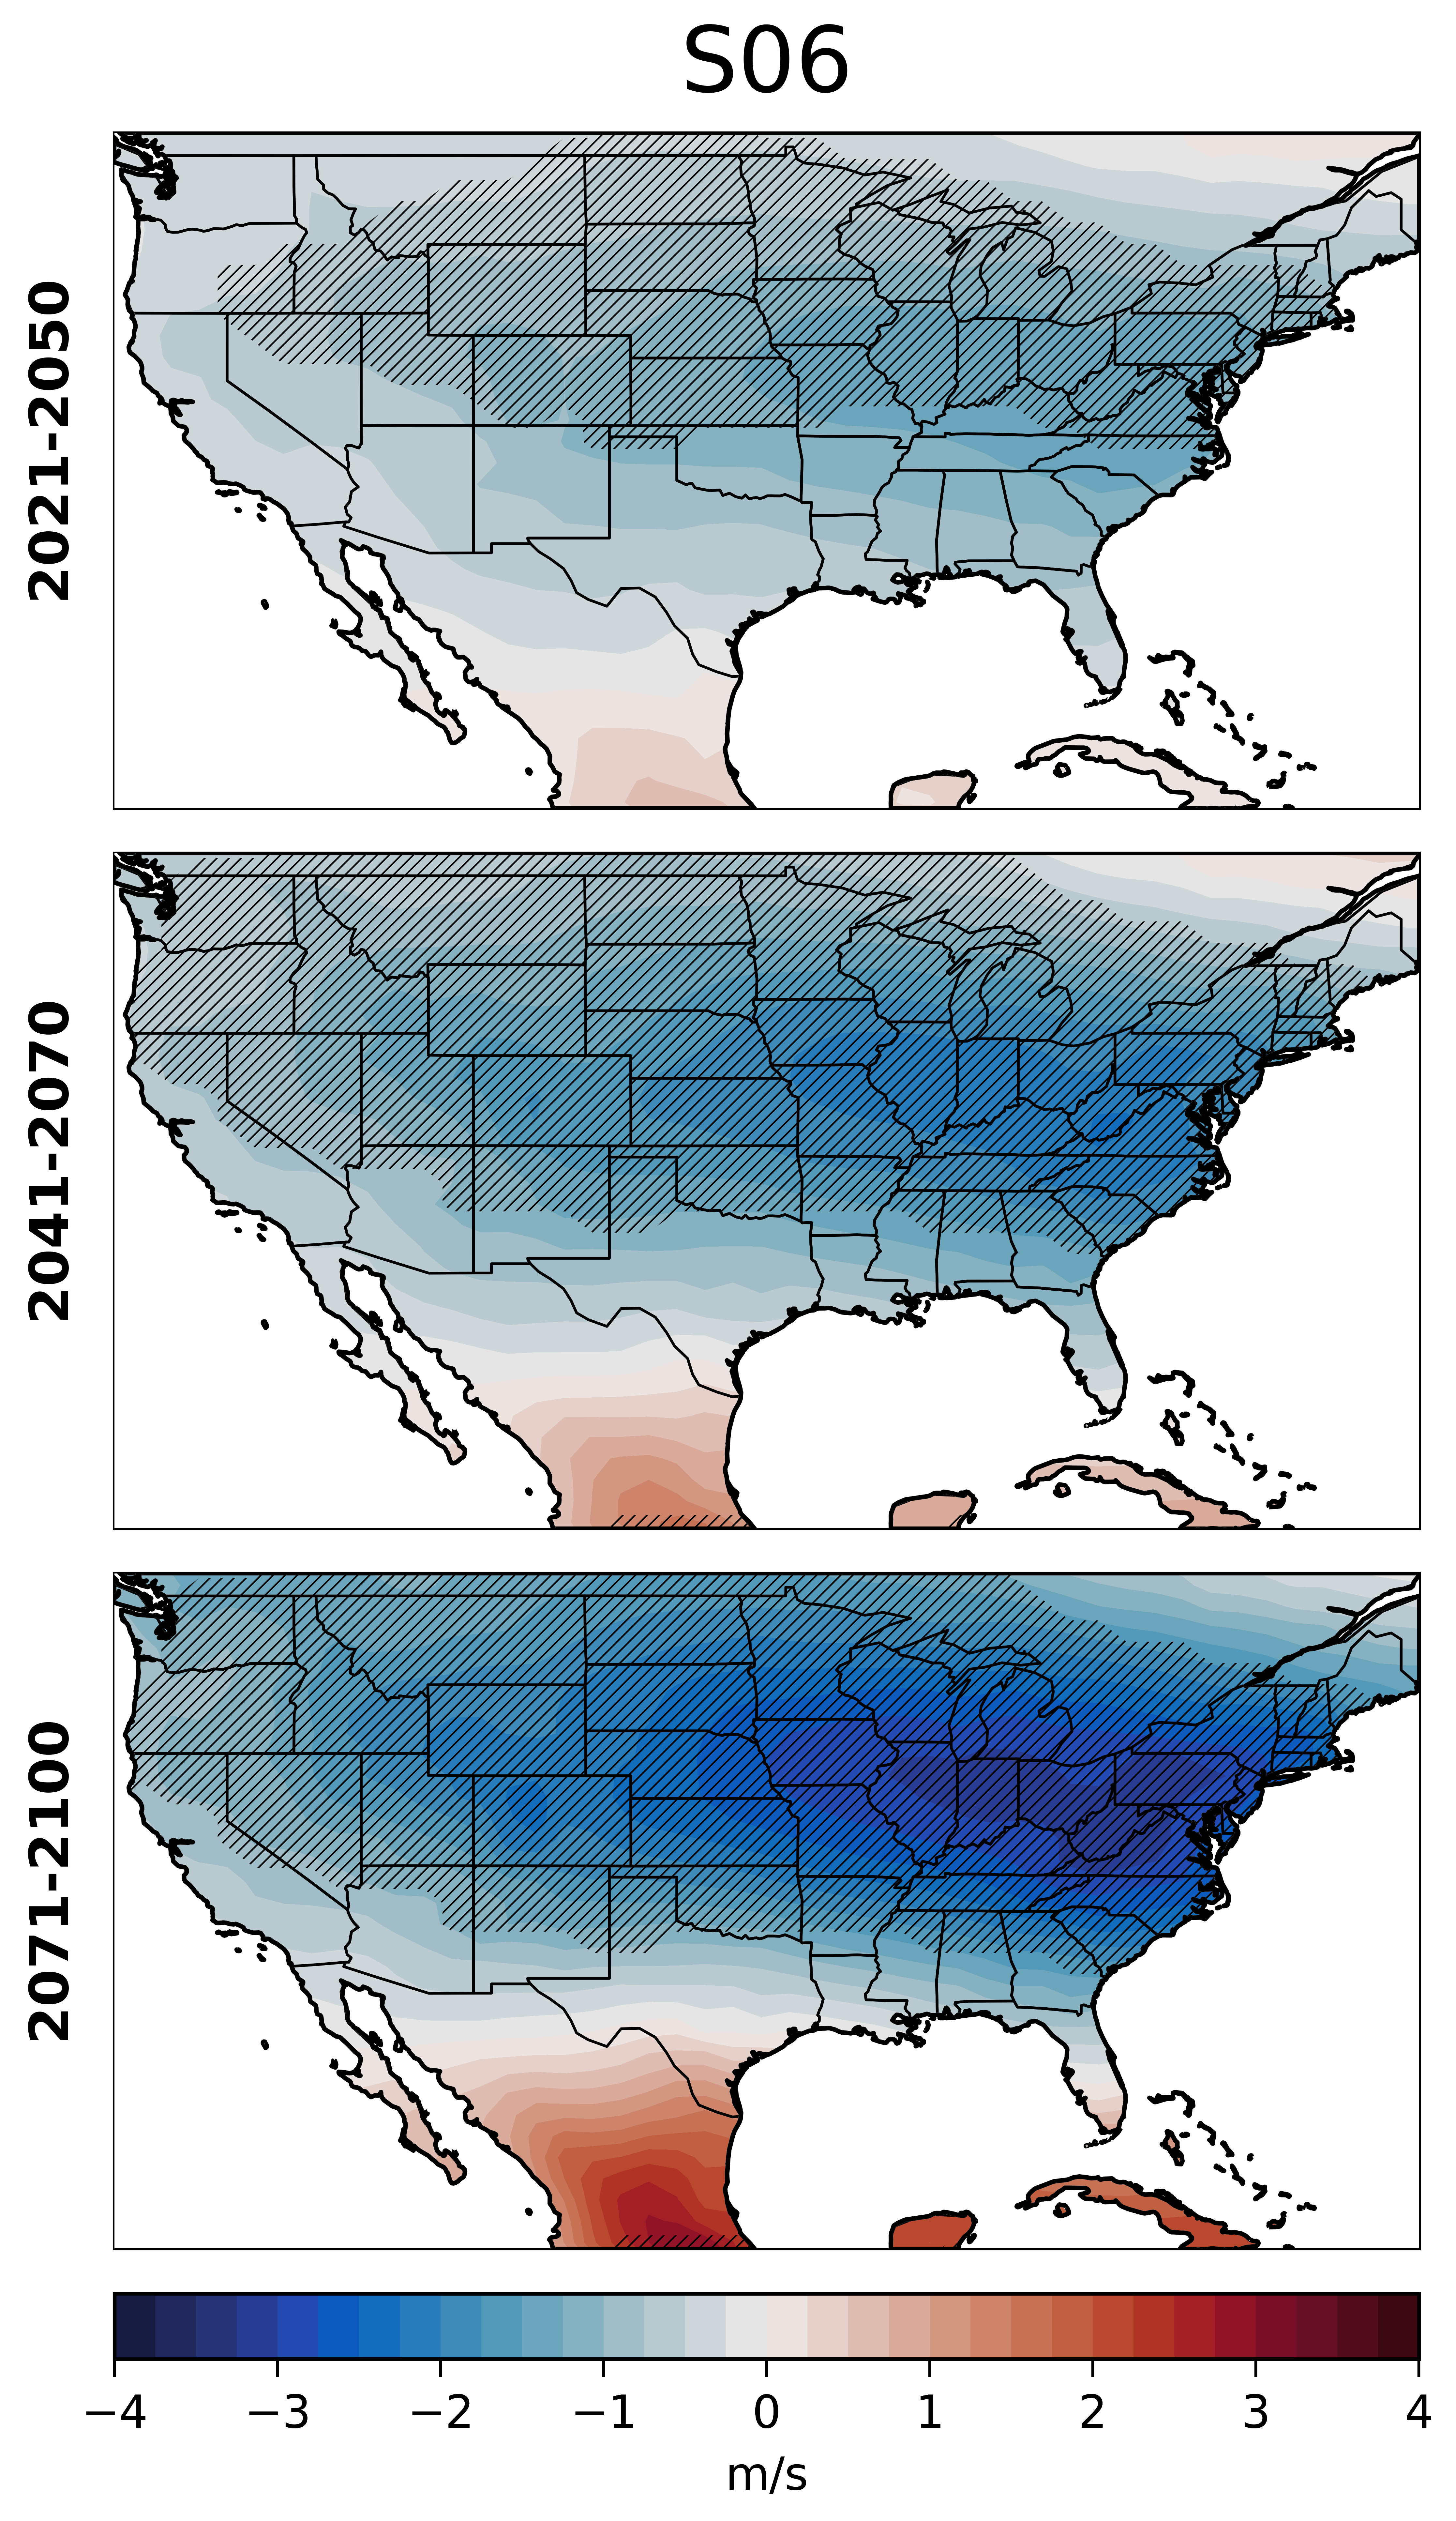

In [ ]:
### S06
plot_title_v2 = 'S06'
save_file_v2 = 's06'
name_v2 = 'S06'
units_v2 = 'm/s'
var_levels_v2 = list(np.arange(-4,4.25,.25))
ticklabel_v2 = ['-3.75','','-2.25','','0.75','0','0.75','','2.25','','3.75']

###---------------------------- 
levels =  var_levels_v2
units = units_v2
plot_title = plot_title_v2
var_levels = var_levels_v2
ticklabel = ticklabel_v2
save_file = save_file_v2
###----------------------------

cmap = 'cmo.balance'
fig, axs = pplt.subplots(ncols=1, nrows=3, axwidth=4, proj='pcarree')   #### originally axwidth of 4
ax3, ax4, ax5 = axs
axs.format(coast = True, latlim = (20,50), lonlim = (235,293), innerborders = True)

fig.suptitle('S06', fontsize = 20)
axs.add_feature(ct.feature.COASTLINE)
axs.add_feature(ct.feature.OCEAN, zorder=100, edgecolor='k', color = 'white')
axs.coastlines(edgecolor = 'k')

a = period1_plot.plot.contourf(ax=ax3, levels = levels, add_colorbar = False, cmap = cmap)  ## , extend = 'neither'  (For CIN)
period2_plot.plot.contourf(ax=ax4, levels =levels, add_colorbar = False, cmap = cmap)  ## , extend = 'neither' (For CIN)
period3_plot.plot.contourf(ax=ax5, levels =levels, add_colorbar = False, cmap = cmap)  ## , extend = 'neither' (For CIN)


### Vertical Titles 
ax3.text(-0.03, .55, p4, fontsize = 12, fontweight = 'bold', va='bottom', ha='center', 
         rotation='vertical', rotation_mode='anchor', transform=ax3.transAxes)
ax4.text(-0.03, .55, p5, fontsize = 12, fontweight = 'bold', va='bottom', ha='center', 
         rotation='vertical', rotation_mode='anchor', transform=ax4.transAxes)
ax5.text(-0.03, .55, p6, fontsize = 12, fontweight = 'bold', va='bottom', ha='center', 
         rotation='vertical', rotation_mode='anchor', transform=ax5.transAxes)

axs.add_feature(ct.feature.COASTLINE, zorder=100, edgecolor='k')

cbar = fig.colorbar(a,  loc="bottom", cmap = cmap, labelsize= 10, label = units, shrink = 1)
cbar.ax.tick_params(labelsize = 10)

ax3.contourf(one.lon, one.lat, one_month_sig_ens, hatches=[None, '/////////'], levels=[0, 2, 4], colors='none')
ax4.contourf(one.lon, one.lat, two_month_sig_ens, hatches=[None, '/////////'], levels=[0, 2, 4], colors='none')
ax5.contourf(one.lon, one.lat, three_month_sig_ens, hatches=[None, '/////////'], levels=[0, 2, 4], colors='none')


# plt.savefig(save_file +"_mamj_epochs_LE2_3PanelFuture_VerticalTitles_FINAL_0924.png", dpi = 500)

